# High F-score vs random baskets — Monte Carlo null

**Question.** Does picking the 30 highest F-score names each year beat picking 30 names at
random from the same investable universe?

**Design.** Both arms are built the *identical* way — equal-weight, `K` names, formed
30/6 every year, held 12 months, no leverage, no costs. The only difference is the
eligible pool:

| arm | selection rule |
|---|---|
| **F-score** | rank the universe by `f_score` descending, take the top `K` |
| **null** | draw `K` names uniformly at random from the same universe |

`N_SIM` random paths give the sampling distribution of each metric under "no skill".
The F-score arm's metric is then read off as a percentile of that distribution.

**Metrics.** CAGR, mean annual return, annual volatility, Sharpe, max drawdown, and
name turnover — all computed from the same per-path series of annual returns.

**Inputs.** `final_panel.csv` only. `fwd_return_1y` is the 30/6 → 30/6 total return
already built in `price_matching_and_finalize`; `tradeable` is the liquidity screen from
`trade_turnover_filter`.

In [14]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

BASE = Path("../data/preprocessing_pipeline_results")
OUT = Path(".")

K = 30                     # basket size, both arms
N_SIM = 2000               # random paths in the null
SEED = 20260810
RF_ANNUAL = 0.0            # Sharpe is excess of this; 0 => raw reward-to-variability
TIEBREAK = "random"        # "random" | "bm" — how F-score ties are resolved
DELISTING_RETURN = None    # None => hold last traded price; else override exit_permanent rows

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 60)
K, N_SIM, TIEBREAK

(30, 2000, 'random')

## 1. Universe

A row is **investable** at formation 30/6/F when it survives every upstream gate at once:

- `tradeable` — passed the 30-day pre-formation liquidity screen (turnover above the
  cross-sectional P10, traded on >= 50% of market sessions)
- `f_score` present — the accounting panel scored all 9 signals
- `bm` present — book-to-market computed (also proves shares and a December price exist)
- `fwd_return_1y` present — both the entry and the exit price were found and the
  12-month holding period has actually finished

Anything failing one of these cannot be *bought*, so it must be excluded from **both**
arms — otherwise the null is drawing from names the strategy never had access to.

In [15]:
panel = pd.read_csv(BASE / "final_panel.csv").set_index(["symbol", "period"])

investable = (panel["tradeable"].eq(True)
              & panel["f_score"].notna()
              & panel["bm"].notna()
              & panel["fwd_return_1y"].notna())

u = panel.loc[investable, ["formation_year", "f_score", "bm",
                           "fwd_return_1y", "exit_permanent"]].copy()
u["formation_year"] = u["formation_year"].astype(int)

if DELISTING_RETURN is not None:
    u.loc[u["exit_permanent"].eq(True), "fwd_return_1y"] = DELISTING_RETURN

u = u.sort_values(["formation_year", "f_score", "bm"], ascending=[True, False, False])
years = np.sort(u["formation_year"].unique())
T = len(years)
symbols = pd.Index(sorted(u.index.get_level_values("symbol").unique()))

print(f"investable rows {len(u):,} / {len(panel):,}"
      f"  |  formation years {years[0]}-{years[-1]} (T = {T})"
      f"  |  distinct symbols {len(symbols):,}")

investable rows 8,780 / 21,233  |  formation years 2012-2025 (T = 14)  |  distinct symbols 1,362


In [16]:
g = u.groupby("formation_year")
universe_stats = pd.DataFrame({
    "n": g.size(),
    "f>=8": g["f_score"].apply(lambda s: int((s >= 8).sum())),
    "f>=9": g["f_score"].apply(lambda s: int((s >= 9).sum())),
    "med_f": g["f_score"].median(),
    "med_ret": g["fwd_return_1y"].median().round(4),
    "mean_ret": g["fwd_return_1y"].mean().round(4),
    "delisted": g["exit_permanent"].sum().astype(int),
})
universe_stats

,n,f>=8,f>=9,med_f,med_ret,mean_ret,delisted
formation_year,,,,,,,
2012,329,26,6,5.0,-0.0153,0.0394,3
2013,416,29,7,5.0,0.3265,0.3885,7
2014,430,51,14,5.0,0.1542,0.2645,4
2015,473,69,11,6.0,0.0901,0.2575,1
2016,515,48,12,5.0,0.0877,0.1848,0
2017,553,65,13,5.0,-0.0671,-0.0075,3
2018,542,60,19,5.0,0.0381,0.1297,3
2019,586,53,14,5.0,-0.0634,-0.0134,1
2020,690,83,17,5.0,0.5122,0.8066,3


## 2. The tie problem

`f_score` is an integer 0-9, so a rank-and-cut at K = 30 almost never lands on a clean
boundary — it lands *inside* a block of names sharing the same score. The table below
shows how many names sit strictly above the cut score and how many are tied at it.

In the years where `above cut = 0`, **every** one of the 30 slots is filled from inside a
single tie block, which means the tiebreak rule is doing all the selecting. Two options:

- `TIEBREAK = "random"` — break ties at random, and repeat the draw `N_SIM` times.
  The F-score arm becomes a distribution too, and it differs from the null in exactly one
  respect: the eligible pool. This isolates the F-score and is the default.
- `TIEBREAK = "bm"` — break ties by book-to-market descending, in Piotroski's spirit
  (he applies F-score *within* high-BM names). Deterministic — BM is a float, and the
  panel contains zero exact `(f_score, bm)` duplicates, so one fixed path. But it adds a
  value ordering the null does not have, so its outperformance cannot be attributed to
  the F-score alone. Section 7 runs it against a **BM-only control** to show what that
  ordering is actually contributing.

Whichever is chosen, the tiebreak is confined to `[0, 1)` while `f_score` is an integer,
so it can only ever reorder names *within* a score — never across two scores. That
invariant is what keeps this a tiebreak rather than a blended signal.

In [17]:
RET, CODE, SCORE, ALT = {}, {}, {}, {}
for y in years:
    d = u[u["formation_year"] == y]
    RET[y] = d["fwd_return_1y"].to_numpy(float)
    CODE[y] = symbols.get_indexer(d.index.get_level_values("symbol"))
    SCORE[y] = d["f_score"].to_numpy(float)
    # deterministic tiebreak mapped into [0, 1) so it can never outrank a whole F point
    ALT[y] = d["bm"].rank(pct=True).to_numpy() * 0.999

ties = []
for y in years:
    s = np.sort(SCORE[y])[::-1]
    cut = s[K - 1]
    ties.append({"formation_year": y, "n": len(s), "cut_score": cut,
                 "above_cut": int((s > cut).sum()), "tied_at_cut": int((s == cut).sum())})
ties = pd.DataFrame(ties).set_index("formation_year")
ties["slots_from_tie"] = K - ties["above_cut"]
ties

,n,cut_score,above_cut,tied_at_cut,slots_from_tie
formation_year,,,,,
2012,329,7.0,26,25,4
2013,416,7.0,29,52,1
2014,430,8.0,14,37,16
2015,473,8.0,11,58,19
2016,515,8.0,12,36,18
2017,553,8.0,13,52,17
2018,542,8.0,19,41,11
2019,586,8.0,14,39,16
2020,690,8.0,17,66,13


## 3. Engine

`draw()` builds a `(n_paths, K)` matrix of selected positions per year. Every arm shares
one ranking key,

```
key = (f_score if use_score else 0) + tiebreak        # tiebreak ∈ [0, 1)
```

so the arms cannot drift apart in construction — they differ only in the two flags of
`ARMS`. Because consecutive F-scores differ by a full point while the tiebreak is bounded
by 1, the tiebreak can only reorder names *within* a score. Dropping `f_score` collapses
the key to pure noise, which is exactly the random null; a deterministic tiebreak
(`fixed=True`) collapses the arm to a single path.

`evaluate()` turns selections into per-path metrics:

- **annual return** — equal-weight mean of `fwd_return_1y` over the K holdings
- **CAGR** — geometric mean of the compounded equity curve
- **Sharpe** — `(mean_annual - RF_ANNUAL) / sd_annual`, ddof = 1, on annual data
- **max drawdown** — worst peak-to-trough on that equity curve. It is measured on
  *annual* points because the panel carries one return per name per year; it is a floor
  on the true intra-year drawdown, not an estimate of it
- **turnover** — one-way name turnover, `1 - |P_t ∩ P_{t+1}| / K`, averaged over the
  13 rebalances. 100% means the basket is replaced wholesale each June

In [18]:
ARMS = {
    #  name        f_score?  tiebreak      deterministic?
    "null":     dict(use_score=False, tiebreak="random", fixed=False),
    "f_rand":   dict(use_score=True,  tiebreak="random", fixed=False),
    "f_bm":     dict(use_score=True,  tiebreak="bm",     fixed=True),
    "bm_only":  dict(use_score=False, tiebreak="bm",     fixed=True),
}


def draw(mode, n_paths, rng):
    """dict year -> (n_paths, K) selected positions, ranked by this arm's key."""
    spec = ARMS[mode]
    out = {}
    for y in years:
        n = len(RET[y])
        k = min(K, n)
        base = SCORE[y] if spec["use_score"] else np.zeros(n)
        if spec["tiebreak"] == "random":
            key = base[None, :] + rng.random((n_paths, n))
        else:
            key = np.broadcast_to(base + ALT[y], (n_paths, n))
        out[y] = np.argpartition(-key, k - 1, axis=1)[:, :k]
    return out


def evaluate(sel, n_paths):
    r = np.empty((n_paths, T))
    for i, y in enumerate(years):
        r[:, i] = RET[y][sel[y]].mean(axis=1)

    equity = np.cumprod(1.0 + r, axis=1)
    peak = np.maximum.accumulate(equity, axis=1)
    mdd = (equity / peak - 1.0).min(axis=1)

    mean_ann = r.mean(axis=1)
    vol_ann = r.std(axis=1, ddof=1)

    rows = np.arange(n_paths)[:, None]
    turn = np.empty((n_paths, T - 1))
    prev = np.zeros((n_paths, len(symbols)), bool)
    prev[rows, CODE[years[0]][sel[years[0]]]] = True
    for i, y in enumerate(years[1:]):
        cur = np.zeros((n_paths, len(symbols)), bool)
        cur[rows, CODE[y][sel[y]]] = True
        turn[:, i] = 1.0 - (cur & prev).sum(1) / sel[y].shape[1]
        prev = cur

    return {"annual": r, "equity": equity,
            "cagr": equity[:, -1] ** (1.0 / T) - 1.0,
            "mean_ann": mean_ann, "vol_ann": vol_ann,
            "sharpe": (mean_ann - RF_ANNUAL) / vol_ann,
            "mdd": mdd, "turnover": turn.mean(axis=1)}


def run(mode, seed, n_sim=None):
    """A deterministic arm collapses to a single path; a random one gets n_sim."""
    n_paths = 1 if ARMS[mode]["fixed"] else (n_sim or N_SIM)
    rng = np.random.default_rng(seed)
    sel = draw(mode, n_paths, rng)
    res = evaluate(sel, n_paths)
    res["sel"], res["mode"], res["n_paths"] = sel, mode, n_paths
    return res


STRATEGY = "f_rand" if TIEBREAK == "random" else "f_bm"
S = run(STRATEGY, SEED)
Z = run("null", SEED + 1)
n_strategy = S["n_paths"]
print(f"strategy arm '{STRATEGY}': {n_strategy:,} path(s)   "
      f"null: {Z['n_paths']:,} paths   K = {K}   T = {T}")

strategy arm 'f_rand': 2,000 path(s)   null: 2,000 paths   K = 30   T = 14


## 4. Metric comparison

`z` is the standardised distance from the null, `(fscore - null_mean) / null_sd` — how
many "random basket" standard deviations the strategy sits away from no-skill. `p_mc` is
the exact Monte-Carlo p-value with the conservative +1 correction,
`(1 + #{null at least as good}) / (1 + N)`; it is one-sided in the metric's natural
direction and two-sided for turnover, where neither end is a priori "better".
`win_rate` pairs every F-score path against every null path.

In [19]:
METRICS = ["cagr", "mean_ann", "vol_ann", "sharpe", "mdd", "turnover"]
DIRECTION = {"cagr": 1, "mean_ann": 1, "sharpe": 1, "mdd": 1, "vol_ann": -1, "turnover": 0}
LABEL = {"cagr": "CAGR", "mean_ann": "mean annual return", "vol_ann": "annual volatility",
         "sharpe": f"Sharpe (rf={RF_ANNUAL:.0%})", "mdd": "max drawdown",
         "turnover": "turnover / rebalance"}

rows = []
for m in METRICS:
    s, z = S[m], Z[m]
    point = s.mean()
    d = DIRECTION[m]
    p_hi = (1 + (z >= point).sum()) / (1 + N_SIM)
    p_lo = (1 + (z <= point).sum()) / (1 + N_SIM)
    p_mc = p_hi if d > 0 else p_lo if d < 0 else min(1.0, 2 * min(p_hi, p_lo))
    rows.append({
        "metric": LABEL[m],
        "fscore": point,
        "fscore_sd": s.std(ddof=1) if len(s) > 1 else np.nan,
        "null_mean": z.mean(),
        "null_sd": z.std(ddof=1),
        "null_p05": np.percentile(z, 5),
        "null_p95": np.percentile(z, 95),
        "z": (point - z.mean()) / z.std(ddof=1),
        "p_mc": p_mc,
        "win_rate": (s[:, None] > z[None, :]).mean(),
    })
comparison = pd.DataFrame(rows).set_index("metric")
comparison.round(4)

,fscore,fscore_sd,null_mean,null_sd,null_p05,null_p95,z,p_mc,win_rate
metric,,,,,,,,,
CAGR,0.2023,0.0129,0.1496,0.0249,0.1103,0.1916,2.1176,0.0185,0.9685
mean annual return,0.2203,0.0142,0.1700,0.0275,0.1267,0.2162,1.8247,0.0385,0.9452
annual volatility,0.2203,0.0175,0.2416,0.0435,0.1825,0.3232,-0.4883,0.3423,0.3464
Sharpe (rf=0%),1.0029,0.0672,0.7144,0.1171,0.5372,0.9255,2.4630,0.0140,0.9767
max drawdown,-0.1146,0.0168,-0.1021,0.0423,-0.1757,-0.0355,-0.2969,0.6342,0.3787
turnover / rebalance,0.8737,0.0100,0.9581,0.0098,0.9410,0.9744,-8.6186,0.0010,0.0000


## 5. t-statistics

Two different questions, two different t-stats:

- **t(level)** — is the F-score portfolio's mean annual return different from zero?
  `mean(r) / (sd(r) / sqrt(T))`. A high value here mostly reflects the fact that
  Vietnamese equities rose over the sample; it is *not* evidence of stock selection.
- **t(spread)** — is the year-by-year gap over the average random basket different from
  zero? Same formula applied to `d_t = r_fscore,t - r_null,t`. Differencing removes the
  common market year effect, so this is the one that speaks to skill. With T = 14 annual
  non-overlapping observations it is a low-power test; treat `p_mc` above and `t(spread)`
  as complements rather than substitutes.

The two are not in competition — they weigh different evidence. `t(spread)` collapses all
8,780 name-years into T = 14 annual numbers and asks whether *those* are stable;
`p_mc` keeps the cross-section intact and asks whether the *ranking* picked well. Expect
`p_mc` to be the sharper of the two, and report both.

All p-values, intervals and power figures come from SciPy (`scipy.stats`).

In [20]:
def tstat(x):
    """Two-sided one-sample t-test against zero."""
    res = stats.ttest_1samp(np.asarray(x, float), 0.0)
    return float(res.statistic), float(res.pvalue)


s_ann = S["annual"].mean(axis=0)          # F-score arm, averaged over tiebreak paths
z_ann = Z["annual"].mean(axis=0)          # expected random basket, year by year
spread = s_ann - z_ann

t_level, p_level = tstat(s_ann)
t_spread, p_spread = tstat(spread)
t_null, p_null = tstat(z_ann)

tests = pd.DataFrame([
    {"test": "t(level) F-score", "mean": s_ann.mean(), "sd": s_ann.std(ddof=1),
     "T": T, "t": t_level, "p_two_sided": p_level},
    {"test": "t(level) null", "mean": z_ann.mean(), "sd": z_ann.std(ddof=1),
     "T": T, "t": t_null, "p_two_sided": p_null},
    {"test": "t(spread) F-score - null", "mean": spread.mean(), "sd": spread.std(ddof=1),
     "T": T, "t": t_spread, "p_two_sided": p_spread},
]).set_index("test")
tests["p_one_sided"] = [
    float(stats.ttest_1samp(x, 0.0, alternative="greater").pvalue)
    for x in (s_ann, z_ann, spread)
]
crit = float(stats.t.ppf(0.975, T - 1))
print(f"critical |t| at 5% two-sided, df = {T - 1}: {crit:.4f}")
tests.round(4)

critical |t| at 5% two-sided, df = 13: 2.1604


,mean,sd,T,t,p_two_sided,p_one_sided
test,,,,,,
t(level) F-score,0.2203,0.2147,14,3.8386,0.0021,0.0010
t(level) null,0.1700,0.2237,14,2.8442,0.0138,0.0069
t(spread) F-score - null,0.0502,0.1272,14,1.4769,0.1635,0.0818


### 5b. Is the t-test even the right test, and could it have found anything?

With T = 14 the parametric t-test rests on the spread being roughly normal, and it is
worth checking rather than assuming. Three families of evidence on the same series:

- **parametric** — `ttest_1samp`, plus the classical t interval
- **distribution-free** — BCa bootstrap interval, Wilcoxon signed-rank, and a sign test.
  If these agree with the t-test, the normality assumption is not doing any work
- **power** — the probability this design would have detected an effect of the size
  observed. This is the number that decides whether a non-rejection means "no effect" or
  "not enough data", and it belongs in the write-up either way.

In [21]:
alpha_lvl = 0.05
tt = stats.ttest_1samp(spread, 0.0)
ci_t = tt.confidence_interval(1 - alpha_lvl)
boot = stats.bootstrap((spread,), np.mean, confidence_level=1 - alpha_lvl,
                       n_resamples=20_000, method="BCa", random_state=SEED)
wil = stats.wilcoxon(spread, alternative="greater")
sgn = stats.binomtest(int((spread > 0).sum()), T, 0.5, alternative="greater")

inference = pd.DataFrame([
    {"test": "t-test (two-sided)", "stat": tt.statistic, "p": tt.pvalue,
     "ci_lo": ci_t.low, "ci_hi": ci_t.high},
    {"test": "t-test (one-sided, >0)", "stat": tt.statistic,
     "p": stats.ttest_1samp(spread, 0.0, alternative="greater").pvalue,
     "ci_lo": np.nan, "ci_hi": np.nan},
    {"test": "bootstrap BCa (20k)", "stat": boot.standard_error, "p": np.nan,
     "ci_lo": boot.confidence_interval.low, "ci_hi": boot.confidence_interval.high},
    {"test": "Wilcoxon signed-rank (>0)", "stat": wil.statistic, "p": wil.pvalue,
     "ci_lo": np.nan, "ci_hi": np.nan},
    {"test": f"sign test ({int((spread > 0).sum())}/{T} years)", "stat": int((spread > 0).sum()),
     "p": sgn.pvalue, "ci_lo": np.nan, "ci_hi": np.nan},
]).set_index("test")

normality = pd.Series({
    "shapiro_W": stats.shapiro(spread).statistic,
    "shapiro_p": stats.shapiro(spread).pvalue,
    "jarque_bera_p": stats.jarque_bera(spread).pvalue,
    "skew": stats.skew(spread),
    "excess_kurtosis": stats.kurtosis(spread),
})
print("normality of the annual spread:")
print(normality.round(4).to_string(), "\n")
inference.round(4)

normality of the annual spread:
shapiro_W          0.9578
shapiro_p          0.6872
jarque_bera_p      0.9211
skew               0.2333
excess_kurtosis   -0.2530 



,stat,p,ci_lo,ci_hi
test,,,,
t-test (two-sided),1.4769,0.1635,-0.0232,0.1237
"t-test (one-sided, >0)",1.4769,0.0818,NaN,NaN
bootstrap BCa (20k),0.0326,NaN,-0.0117,0.1168
Wilcoxon signed-rank (>0),76.0000,0.0765,NaN,NaN
sign test (10/14 years),10.0000,0.0898,NaN,NaN


In [22]:
def power_at(n, effect, alpha=0.05, alternative="two-sided"):
    """Power of a one-sample t-test via the noncentral t distribution."""
    dfn = n - 1
    ncp = effect * np.sqrt(n)
    if alternative == "two-sided":
        crit = stats.t.ppf(1 - alpha / 2, dfn)
        return float(stats.nct.sf(crit, dfn, ncp) + stats.nct.cdf(-crit, dfn, ncp))
    crit = stats.t.ppf(1 - alpha, dfn)
    return float(stats.nct.sf(crit, dfn, ncp))


def years_for(target, effect, alternative="two-sided"):
    return next((n for n in range(5, 1000)
                 if power_at(n, effect, alternative=alternative) >= target), np.nan)


effect = spread.mean() / spread.std(ddof=1)          # Cohen's d on the annual spread
power = pd.DataFrame([
    {"alternative": alt,
     "power_at_T": power_at(T, effect, alternative=alt),
     "T_for_50%": years_for(0.50, effect, alt),
     "T_for_80%": years_for(0.80, effect, alt)}
    for alt in ["two-sided", "greater"]
]).set_index("alternative")
print(f"observed effect size (Cohen's d) = {effect:.4f}"
      f"   |   mean spread {spread.mean():.2%}, sd {spread.std(ddof=1):.2%}, T = {T}\n")
power.round(3)

observed effect size (Cohen's d) = 0.3947   |   mean spread 5.02%, sd 12.72%, T = 14



,power_at_T,T_for_50%,T_for_80%
alternative,,,
two-sided,0.278,27,53
greater,0.403,19,42


In [23]:
annual = pd.DataFrame({
    "fscore": s_ann,
    "null_mean": z_ann,
    "spread": spread,
    "null_p05": np.percentile(Z["annual"], 5, axis=0),
    "null_p95": np.percentile(Z["annual"], 95, axis=0),
    "pctile": [(Z["annual"][:, i] < s_ann[i]).mean() * 100 for i in range(T)],
}, index=pd.Index(years, name="formation_year"))
annual["beat_null"] = annual["spread"] > 0
print(f"years beating the average random basket: "
      f"{int(annual['beat_null'].sum())}/{T}"
      f"   |   years above the null's 95th pctile: {int((annual['pctile'] > 95).sum())}")
annual.round(4)

years beating the average random basket: 10/14   |   years above the null's 95th pctile: 2


,fscore,null_mean,spread,null_p05,null_p95,pctile,beat_null
formation_year,,,,,,,
2012,0.3322,0.0391,0.2931,-0.0864,0.1756,100.00,True
2013,0.4255,0.3871,0.0384,0.2356,0.5506,67.45,True
2014,0.5228,0.2666,0.2562,0.1029,0.4793,96.95,True
2015,0.3287,0.2595,0.0692,0.0705,0.4969,73.90,True
2016,0.1127,0.1799,-0.0672,0.0319,0.3698,28.45,False
2017,0.0811,-0.0089,0.0900,-0.1178,0.1179,88.85,True
2018,0.2100,0.1283,0.0816,-0.0108,0.3107,80.30,True
2019,0.0063,-0.0134,0.0197,-0.1152,0.1043,63.10,True
2020,0.6420,0.8079,-0.1659,0.5429,1.1797,18.55,False


## 6. Charts

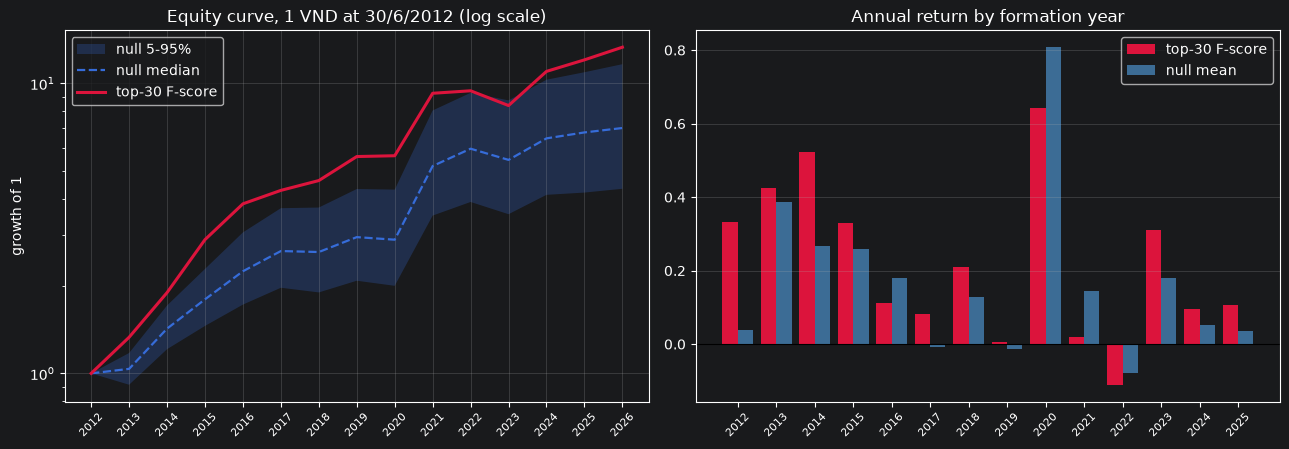

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))

x = np.arange(T + 1)
band_lo = np.concatenate([[1.0], np.percentile(Z["equity"], 5, axis=0)])
band_hi = np.concatenate([[1.0], np.percentile(Z["equity"], 95, axis=0)])
null_med = np.concatenate([[1.0], np.median(Z["equity"], axis=0)])
strat = np.concatenate([[1.0], S["equity"].mean(axis=0)])

ax[0].fill_between(x, band_lo, band_hi, alpha=0.25, label="null 5-95%")
ax[0].plot(x, null_med, lw=1.6, ls="--", label="null median")
ax[0].plot(x, strat, lw=2.2, color="crimson", label=f"top-{K} F-score")
ax[0].set_yscale("log")
ax[0].set_xticks(x)
ax[0].set_xticklabels([str(years[0])] + [str(y + 1) for y in years], rotation=45, fontsize=8)
ax[0].set_title(f"Equity curve, 1 VND at 30/6/{years[0]} (log scale)")
ax[0].set_ylabel("growth of 1")
ax[0].legend()
ax[0].grid(alpha=0.3)

ax[1].bar(years - 0.2, s_ann, width=0.4, color="crimson", label=f"top-{K} F-score")
ax[1].bar(years + 0.2, z_ann, width=0.4, color="steelblue", alpha=0.8, label="null mean")
ax[1].axhline(0, color="black", lw=0.8)
ax[1].set_title("Annual return by formation year")
ax[1].set_xticks(years)
ax[1].set_xticklabels(years, rotation=45, fontsize=8)
ax[1].legend()
ax[1].grid(alpha=0.3, axis="y")

fig.tight_layout()
fig.savefig(OUT / "fscore_vs_random_curves.png", dpi=150)
plt.show()

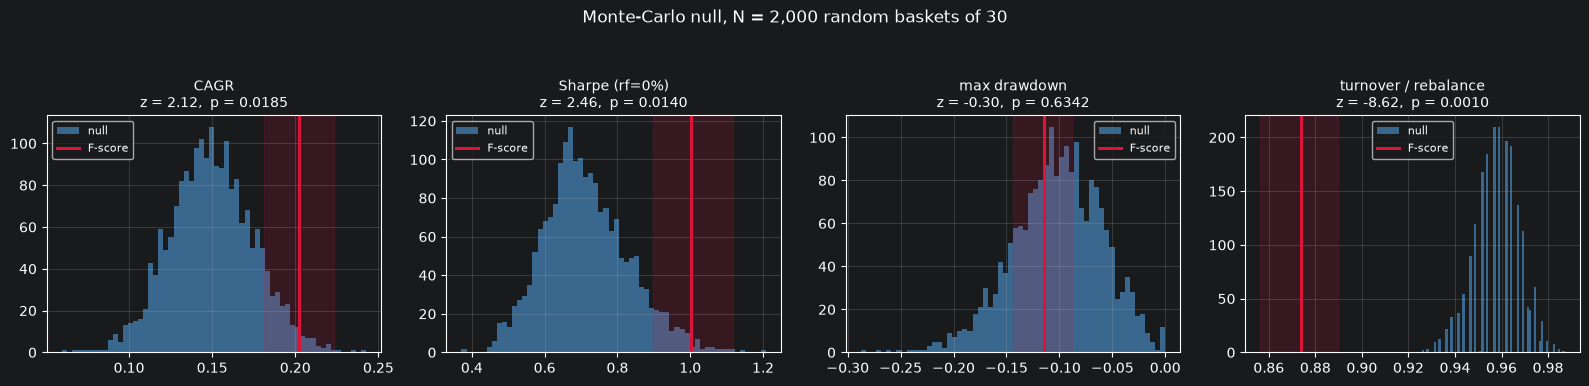

In [25]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.6))
for axis, m in zip(axes, ["cagr", "sharpe", "mdd", "turnover"]):
    axis.hist(Z[m], bins=60, color="steelblue", alpha=0.75, label="null")
    axis.axvline(S[m].mean(), color="crimson", lw=2.2, label="F-score")
    if len(S[m]) > 1:
        axis.axvspan(np.percentile(S[m], 5), np.percentile(S[m], 95),
                     color="crimson", alpha=0.15)
    row = comparison.loc[LABEL[m]]
    axis.set_title(f"{LABEL[m]}\nz = {row['z']:.2f},  p = {row['p_mc']:.4f}", fontsize=10)
    axis.legend(fontsize=8)
    axis.grid(alpha=0.3)
fig.suptitle(f"Monte-Carlo null, N = {N_SIM:,} random baskets of {K}", y=1.06)
fig.tight_layout()
fig.savefig(OUT / "fscore_vs_random_nulls.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Robustness — basket size, tie rule, and a pure-value control

Three arms, all scored against the **same** null (`alpha = 0` short-circuits the tie rule,
so the null draws are identical across arms at a given seed and K):

| arm | ranking key | what it isolates |
|---|---|---|
| `f_rand` | `f_score` + uniform noise | F-score alone — the headline spec |
| `f_bm` | `f_score` + BM rank | F-score, ties resolved toward value |
| `bm_only` | BM rank alone | **value alone**, F-score ignored |

`bm_only` is the control that makes `f_bm` interpretable. If the extra return in `f_bm`
were simply an imported value premium, a portfolio sorted on BM alone would earn it too.
Watch whether it does.

In [26]:
def experiment(k, mode, n_sim=N_SIM, seed=SEED):
    global K
    keep, K = K, k
    try:
        s = run(mode, seed, n_sim)
        z = run("null", seed + 1, n_sim)
    finally:
        K = keep
    out = {"arm": mode, "K": k}
    for m in ["cagr", "sharpe", "mdd", "turnover"]:
        point = s[m].mean()
        d = DIRECTION[m]
        p_hi = (1 + (z[m] >= point).sum()) / (1 + n_sim)
        p_lo = (1 + (z[m] <= point).sum()) / (1 + n_sim)
        out[m] = point
        out[f"p_{m}"] = p_hi if d > 0 else p_lo if d < 0 else min(1.0, 2 * min(p_hi, p_lo))
    out["null_cagr"] = z["cagr"].mean()
    spread_k = s["annual"].mean(0) - z["annual"].mean(0)
    out["spread"] = spread_k.mean()
    out["spread_sd"] = spread_k.std(ddof=1)
    out["t_spread"], out["p_spread"] = tstat(spread_k)
    out["wins"] = int((spread_k > 0).sum())
    return out


robustness = pd.DataFrame([experiment(k, arm)
                           for arm in ["f_rand", "f_bm", "bm_only"]
                           for k in [10, 20, 30, 50, 100]])
robustness.set_index(["arm", "K"]).round(4)

cagr  p_cagr  sharpe  p_sharpe     mdd   p_mdd  turnover  p_turnover  null_cagr  spread  spread_sd  t_spread  p_spread  wins
arm     K                                                                                                                                  
f_rand  10   0.2362  0.0180  1.0136    0.0175 -0.1546  0.4698    0.9286       0.001     0.1422  0.0914     0.1740    1.9653    0.0711    10
        20   0.2141  0.0200  1.0134    0.0170 -0.1214  0.5437    0.9011       0.001     0.1478  0.0639     0.1473    1.6228    0.1286    10
        30   0.2023  0.0185  1.0029    0.0140 -0.1146  0.6342    0.8737       0.001     0.1496  0.0502     0.1272    1.4769    0.1635    10
        50   0.1923  0.0150  1.0016    0.0065 -0.0944  0.5687    0.8398       0.001     0.1506  0.0388     0.1073    1.3540    0.1988     9
        100  0.1924  0.0010  0.9940    0.0010 -0.0764  0.4583    0.7879       0.001     0.1525  0.0380     0.0821    1.7289    0.1075    10
f_bm    10   0.2879  0.0015  1.1197    0.0085 -0.0545  0.0585    0.9385       0.001     0.1422  0.1435     0.1662    3.2314    0.0066    12
        20   0.2542  0.0020  1.0130    0.0170 -0.0933  0.3173    0.8923       0.001     0.1478  0.1093     0.1616    2.5306    0.0251    10
        30   0.2491  0.0005  1.0082    0.0135 -0.0893  0.3983    0.8769       0.001     0.1496  0.1034     0.1458    2.6529    0.0199    11
        50   0.2199  0.0010  0.9975    0.0065 -0.1069  0.7161    0.8508       0.001     0.1506  0.0707     0.0994    2.6611    0.0196    10
        100  0.2066  0.0005  0.9464    0.0030 -0.0775  0.4748    0.7923       0.001     0.1525  0.0554     0.0703    2.9491    0.0113    11
bm_only 10   0.1521  0.3858  0.3209    0.9865 -0.2590  0.8746    0.7231       0.001     0.1422  0.1304     0.7433    0.6562    0.5232     5
        20   0.1275  0.7401  0.3186    1.0000 -0.3215  0.9995    0.6692       0.001     0.1478  0.0749     0.5695    0.4919    0.6310     5
        30   0.1298  0.7901  0.3442    1.0000 -0.2297  0.9965    0.6308       0.001     0.1496  0.0510     0.4454    0.4282    0.6755     4
        50   0.1733  0.1289  0.4700    0.9995 -0.1252  0.8636    0.5600       0.001     0.1506  0.0637     0.2969    0.8023    0.4368     7
        100  0.1743  0.0415  0.5421    0.9995 -0.0979  0.7751    0.4831       0.001     0.1525  0.0462     0.1975    0.8759    0.3970     8

The `bm_only` row is the surprise, and it is the reason the `f_bm` result must not be
described as a value premium: sorting on book-to-market **alone** compounds *below* the
equal-weighted market despite a high arithmetic mean — the gap between the two is
volatility drag, and it wins in a minority of years.

So `f_bm` is not `f_rand` plus a standalone value factor; the two do not add. BM ranking
only pays *inside* the financially strong block, which is Piotroski's own thesis read in
mirror: value alone is a trap, and the F-score is what separates the winners in it.

That does not promote `f_bm` to the default. It still differs from the null in **two**
ways — restricted pool *and* value ordering — so its `t(spread)` cannot be attributed to
the F-score alone. `f_rand` remains the spec that answers the stated question; `f_bm` and
`bm_only` belong in the robustness discussion, where a reader can see the interaction for
what it is.

In [27]:
arms_at_k = (robustness[robustness["K"] == K]
             .set_index("arm")[["cagr", "null_cagr", "sharpe", "spread",
                                "spread_sd", "t_spread", "p_spread", "wins"]])
print(f"K = {K}, T = {T}, critical |t| at 5% two-sided = ~2.16\n")
arms_at_k.round(4)

K = 30, T = 14, critical |t| at 5% two-sided = ~2.16



,cagr,null_cagr,sharpe,spread,spread_sd,t_spread,p_spread,wins
arm,,,,,,,,
f_rand,0.2023,0.1496,1.0029,0.0502,0.1272,1.4769,0.1635,10
f_bm,0.2491,0.1496,1.0082,0.1034,0.1458,2.6529,0.0199,11
bm_only,0.1298,0.1496,0.3442,0.0510,0.4454,0.4282,0.6755,4


## 8. Holdings

Under a random tiebreak the basket is not a single fixed list, so the honest summary is a
**selection frequency**: the share of the `N_SIM` F-score paths that held a given name in
a given year. Names at frequency 1.00 are unambiguous picks — their F-score was strictly
above the cut, so no tiebreak could dislodge them. Anything below 1.00 sits inside a tie
block.

In [28]:
freq_rows = []
for i, y in enumerate(years):
    counts = np.bincount(S["sel"][y].ravel(), minlength=len(RET[y]))
    d = u[u["formation_year"] == y]
    held = counts > 0
    freq_rows.append(pd.DataFrame({
        "formation_year": y,
        "symbol": d.index.get_level_values("symbol")[held],
        "period": d.index.get_level_values("period")[held],
        "f_score": SCORE[y][held],
        "bm": d["bm"].to_numpy()[held],
        "fwd_return_1y": RET[y][held],
        "hold_freq": counts[held] / n_strategy,
    }))
holdings = (pd.concat(freq_rows)
            .sort_values(["formation_year", "hold_freq", "f_score"], ascending=[True, False, False])
            .reset_index(drop=True))

certain = holdings[holdings["hold_freq"] >= 0.999]
print(f"candidate name-years touched by at least one path: {len(holdings):,}")
print(f"always held (freq = 1.00): {len(certain):,}  "
      f"-> {len(certain) / T:.1f} of the {K} slots per year on average")
(holdings.groupby("formation_year")
         .agg(candidates=("symbol", "size"),
              always_held=("hold_freq", lambda s: int((s >= 0.999).sum())),
              min_f=("f_score", "min"),
              mean_f=("f_score", "mean"))
         .assign(portfolio_return=annual["fscore"].to_numpy())
         .round(3))

candidate name-years touched by at least one path: 825
always held (freq = 1.00): 189  -> 13.5 of the 30 slots per year on average


,candidates,always_held,min_f,mean_f,portfolio_return
formation_year,,,,,
2012,51,26,7.0,7.627,0.332
2013,81,29,7.0,7.444,0.425
2014,51,14,8.0,8.275,0.523
2015,69,11,8.0,8.159,0.329
2016,48,12,8.0,8.250,0.113
2017,65,13,8.0,8.200,0.081
2018,60,19,8.0,8.317,0.210
2019,53,14,8.0,8.264,0.006
2020,83,17,8.0,8.205,0.642


## 9. Exports

In [29]:
comparison.to_csv(OUT / "fscore_vs_random_metrics.csv")
annual.to_csv(OUT / "fscore_vs_random_annual.csv")
tests.to_csv(OUT / "fscore_vs_random_tstats.csv")
inference.to_csv(OUT / "fscore_vs_random_inference.csv")
power.to_csv(OUT / "fscore_vs_random_power.csv")
robustness.to_csv(OUT / "fscore_vs_random_robustness.csv", index=False)
holdings.to_csv(OUT / "fscore_top_k_holdings.csv", index=False)

null_draws = pd.DataFrame({m: Z[m] for m in METRICS})
null_draws.to_csv(OUT / "fscore_vs_random_null_draws.csv", index=False)

for f in sorted(OUT.glob("fscore_*")):
    print(f"{f.name:40s} {f.stat().st_size / 1024:8.1f} KB")

fscore_top_k_holdings.csv                    49.5 KB
fscore_vs_random_annual.csv                   1.7 KB
fscore_vs_random_curves.png                 102.0 KB
fscore_vs_random_inference.csv                0.4 KB
fscore_vs_random_metrics.csv                  1.2 KB
fscore_vs_random_montecarlo.ipynb           247.8 KB
fscore_vs_random_null_draws.csv             229.7 KB
fscore_vs_random_nulls.png                   87.6 KB
fscore_vs_random_power.csv                    0.1 KB
fscore_vs_random_robustness.csv               4.0 KB
fscore_vs_random_tstats.csv                   0.4 KB


## 10. Reading the result

- **The comparison is like-for-like.** Both arms hold `K` equal-weighted names drawn from
  the same investable universe on the same dates, so the only thing being tested is the
  ranking rule.
- **`p_mc` is the headline test, `t(spread)` is the honest caveat.** The Monte-Carlo
  p-value conditions on the realised market path — it asks "given these 14 years, could a
  blindfolded picker have done this well?". The paired t-stat instead asks whether the
  edge is stable enough across those 14 years to reject zero, and 14 non-overlapping
  annual observations is simply not much data. They can disagree, and when they do it
  means the edge is real in this sample but not yet distinguishable from luck in the
  time-series dimension.
- **The design is underpowered, and section 5b quantifies it.** At the observed effect
  size the paired test had roughly a **28%** chance of rejecting at 5% two-sided even if
  the edge is exactly as large as measured. A non-rejection here carries very little
  evidence *against* the strategy — it mostly reflects T = 14. Reaching conventional 80%
  power at this effect size needs on the order of 50 annual observations, which is longer
  than the market has existed; the way to buy power is a denser design (monthly
  overlapping formations, or cross-sectional Fama-MacBeth), not a longer wait.
- **Normality is not the problem.** Shapiro and Jarque-Bera both clear comfortably and the
  bootstrap interval nearly coincides with the t interval, so the t-test is not being
  distorted by the two bad years — the interval is wide because the data are few.
- **No transaction costs.** Turnover is reported so that a cost assumption can be applied
  afterwards: one-way turnover `x` at cost `c` per side reduces the annual return by
  roughly `2 * x * c`.
- **Max drawdown is annual-granularity** and therefore understates the true drawdown an
  investor would have lived through.
- **Survivorship is handled upstream, not here.** `fwd_return_1y` comes from an as-of
  price lookup, and names that stopped trading keep their last traded price
  (`exit_permanent`). Set `DELISTING_RETURN` in cell 2 to haircut those instead.